## Notebook 4: Impact Functions

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
SUMMARY OF NOTEBOOK
</blockquote>

In [1]:
# Repo-root discovery + import of cityheat
import sys
from pathlib import Path

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError("Could not find repo root with 'cityheat' and 'configs' folders.")

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
C = bootstrap("Rome")  # switch to "Barcelona" later

PROJECT, CITY, CFG, cfg = C["PROJECT"], C["CITY"], C["CFG"], C["cfg"]
OUT, INT, BASE = C["OUT"], C["INT"], C["BASE"]
p_LCZ, p_UrbClim, p_GVI, p_CoolEff = C["p_LCZ"], C["p_UrbClim"], C["p_GVI"], C["p_CoolEff"]

print("Repo root:", ROOT)
print("✔ Loaded config:", CFG)
print("→ Outputs:", OUT)
print("→ Data base:", BASE)

Repo root: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat
✔ Loaded config: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/configs/rome.yml
→ Outputs: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome
→ Data base: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome


**from Notebook 3**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from climada.hazard import Hazard
from climada.entity.exposures import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc

plt.rcParams.update({"figure.dpi": 130})

# loading hazard and exposure produced in Notebook 3
haz_path = INT / "hazard_HEAT.h5"
exp_path = INT / "exposure_people.h5"

H = Hazard()
H.read_hdf5(haz_path)

exp = Exposures()
exp.read_hdf5(exp_path)

# we'll reuse this a lot:
years = [int(y) for y in H.event_id.tolist()]

print("Hazard events:", years)
print("Exposure rows:", len(exp.gdf))
print(exp.gdf.head())

2025-11-06 13:17:36,425 - climada.hazard.io - WARNING - The use of Hazard.read_hdf5 is deprecated.Use Hazard.from_hdf5 instead.
2025-11-06 13:17:36,587 - climada.entity.exposures.base - WARNING - The use of Exposures.read_hdf5 is deprecated.Use Exposures.from_hdf5 instead.
Hazard events: [2030, 2050, 2070, 2090, 2100]
Exposure rows: 228150
      value age_group  impf_HEAT                   geometry
0  0.001538       <15          1  POINT (12.30533 42.00025)
1  0.101227       <15          1  POINT (12.30638 42.00025)
2  0.339543       <15          1  POINT (12.30744 42.00025)
3  0.505446       <15          1  POINT (12.30849 42.00025)
4  0.365750       <15          1  POINT (12.30955 42.00025)


Age-group population totals from exp (because later we do per-100k by group)

In [3]:
age_pop = (
    exp.gdf.groupby("age_group")["value"]
    .sum()
    .astype(float)
    .sort_index()
)
print("Population by age group on WBGT grid:")
print(age_pop)
print("Total population on WBGT grid:", float(age_pop.sum()))

Population by age group on WBGT grid:
age_group
15-64    1.581728e+06
65+      6.912688e+05
<15      2.773887e+05
Name: value, dtype: float64
Total population on WBGT grid: 2550385.606954236


> **Impact Funtions in Climada:**
> - how intensity → damage
> - “intensity” = how many very hot WBGT days per year in that pixel (e.g. 45 days > 28°C)
> - “Damage” = heat mortality per person (deaths per person per year) (MDD: mean damage degree)
> - We want three different curves: `&lt;15`, 15–64, 65+
>   - intuition : older people die more of heat, even at slightly milder
>     conditions. Kids are vulnerable but absolute numbers are tiny because baseline
>     mortality is already very low. Working-age adults are in the middle.
> - Defining a threshold `tau_days` where risk kicks in, and a curvature `gamma` that says how fast mortality explodes when we get more and more extreme heat. Smaller `tau` / higher `gamma` = more fragile.

**helpers**

In [4]:
def subset_exposure_by_age(exp_obj, age_label):
    """
    Return a new Exposures with only rows for one age group.
    This lets us run impacts for each age group separately.
    """
    mask = exp_obj.gdf["age_group"] == age_label
    if not mask.any():
        return None
    sub = Exposures()
    sub.set_gdf(exp_obj.gdf.loc[mask].copy())
    sub.value_unit = exp_obj.value_unit
    sub.tag = f"{getattr(exp_obj, 'tag', 'exp')} — {age_label}"
    return sub

def run_and_rates(exp_obj, H, if_set_dict):
    """
    Run CLIMADA ImpactCalc for a given exposure, hazard, and IF set.

    Returns:
    - totals: number of heat deaths per event (same order as H.event_id)
    - rate_per_100k: totals divided by that sub-exposure's population * 100k
    """
    ifs = ImpactFuncSet(list(if_set_dict.values()))
    ifs.check()

    imp = ImpactCalc(exp_obj, ifs, H).impact()
    totals = np.ravel(imp.at_event)  # deaths per event (each event is one "year")

    pop_total = float(exp_obj.gdf["value"].sum())
    rate_per_100k = totals / pop_total * 1e5 if pop_total > 0 else np.zeros_like(totals)

    return totals, rate_per_100k

def run_by_age(exp_obj, H, if_set_by_age):
    """
    For each age group, run impact using only that group's exposure rows
    and that group's IF, and return totals and per-100k.
    """
    out = {}
    for age_label, impf in if_set_by_age.items():
        sub = subset_exposure_by_age(exp_obj, age_label)
        if (sub is None) or (float(sub.gdf["value"].sum()) == 0):
            out[age_label] = {
                "totals":   np.zeros(len(H.event_id)),
                "per100k":  np.zeros(len(H.event_id)),
            }
        else:
            totals, rates = run_and_rates(sub, H, {age_label: impf})
            out[age_label] = {"totals": totals, "per100k": rates}
    return out

**building the raw shape of each age group’s IF**

In [5]:
def make_power_if_days(H, tau_days, gamma, impf_id, name):
    """
    Build a convex "turn-on after tau" curve in (hot days/year) space.
    tau_days: how many very hot days per year before mortality really starts
    gamma:    how steep after that point
    """
    I_max = float(H.intensity.max()) * 1.05  # slightly above observed max
    x = np.linspace(0.0, max(1.0, I_max), 128)

    # 0 below tau, then (x - tau)^gamma above tau
    y = np.maximum(0.0, x - float(tau_days)) ** float(gamma)

    # pre-scale roughly into a tiny mortality probability per person-year
    if y.max() > 0:
        y = y / y.max() * 1e-3  # arbitrary small scale; we'll re-anchor later
    else:
        y = np.zeros_like(x)

    impf = ImpactFunc(
        haz_type='HEAT',
        id=int(impf_id),
        intensity=x.astype(float),
        mdd=y.astype(float),
        paa=np.ones_like(x, dtype=float),
        name=f"{name} (τ={tau_days}, γ={gamma})"
    )
    impf.check()
    return impf

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Defining three age curves, using tau and gamma. The intuition is: elderly curve turns on earlier (low tau_days) and rises faster (higher gamma)
</blockquote>

In [6]:
AGE_PARAMS = {
    "<15":   dict(tau_days=15.0, gamma=1.6, impf_id=1, name="Heat mortality · <15"),
    "15-64": dict(tau_days=10.0, gamma=2.0, impf_id=2, name="Heat mortality · 15-64"),
    "65+":   dict(tau_days= 6.0, gamma=2.6, impf_id=3, name="Heat mortality · 65+"),
}

def make_age_if_set(H, age_params=AGE_PARAMS):
    return {grp: make_power_if_days(H, **p) for grp, p in age_params.items()}

age_ifs = make_age_if_set(H)

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Weighting IFs by realistic baseline mortality. Intuition: we weight because even if heat sensitivity is similar in shape, old people just die more in general. A 1% increase in mortality in a group with very high baseline mortality is a lot of absolute deaths. So we multiply each curve so that the 65+ curve is scaled up in absolute terms compared to the 15–64 curve, and the <15 curve is scaled down, using age-group baseline all-cause mortality rates (per 100k people per year).
</blockquote>

In [7]:
BASELINE_PER100K = {
    "<15":   1.7,
    "15-64": 70.0,
    "65+":   3129.0,
}

In [8]:
def weight_ifset_by_baseline(if_set, baseline_per100k, ref_age="15-64"):
    """
    Multiply each age IF's MDD by (baseline_age / baseline_ref).

    Intuition:
    - Keep 15-64 as reference scale = 1.
    - Elderly get multiplied by (elderly baseline / adult baseline) >> 1.
    - Kids get multiplied by (kids baseline / adult baseline) << 1.
    """
    ref = float(baseline_per100k[ref_age])
    for age, f in if_set.items():
        f.mdd *= float(baseline_per100k[age]) / ref

weight_ifset_by_baseline(age_ifs, BASELINE_PER100K, ref_age="15-64")

Now the elderly IF is not just “steeper,” it also sits higher in absolute terms.

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Anchoring the total level to a target (e.g. 91 per 100k in 2050). Right now, the curves have the right shape and the right relative height across ages, but the absolute height (how many deaths we predict) is still arbitrary. We fix that by scaling all three curves together so that, in 2050, the overall heat mortality matches some target rate from the literature.
</blockquote>

In [9]:
import numpy as np

# repairing hazard metadata lost on HDF5 round-trip
if not hasattr(H, "event_name") or len(getattr(H, "event_name", [])) != len(H.event_id):
    H.event_name = np.array([f"HEAT_{int(y)}" for y in H.event_id], dtype=object)

if not hasattr(H, "date") or len(getattr(H, "date", [])) != len(H.event_id):
    H.date = np.array([np.datetime64(f"{int(y)}-07-01") for y in H.event_id])

if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != len(H.event_id):
    H.frequency = np.ones(len(H.event_id), dtype=float)

In [10]:
def _pick_anchor_rate(rates, H, anchor_event):
    # choosing which event/year to match
    years_list = [int(y) for y in H.event_id.tolist()]
    if anchor_event in years_list:
        idx = years_list.index(anchor_event)
        return float(rates[idx])
    # fallback: average across events
    return float(rates.mean()) if rates.size > 1 else float(rates)

def scale_ifset_to_total_anchor(exp_obj, H, if_set, target_per100k,
                                heat_share=1.0, anchor_event=None):
    """
    Multiply *all* age IFs by one common factor so that
    overall per-100k == target_per100k * heat_share
    for the chosen anchor event.
    """
    # running once with current scaling
    _, r0 = run_and_rates(exp_obj, H, if_set)
    current = _pick_anchor_rate(r0, H, anchor_event)
    target  = float(target_per100k) * float(heat_share)

    scale = (target / current) if current > 0 else 1.0
    for f in if_set.values():
        f.mdd *= scale
    return scale

TOTAL_TARGET_PER100K = 91.0   # desired overall heat mortality per 100k
HEAT_SHARE = 1.0             # if target is already "heat only", keep 1.0
ANCHOR_EVENT = 2050          # match the 2050 event

scale_all = scale_ifset_to_total_anchor(
    exp, H, age_ifs,
    target_per100k=TOTAL_TARGET_PER100K,
    heat_share=HEAT_SHARE,
    anchor_event=ANCHOR_EVENT
)

print("Global scale factor applied:", scale_all)

Global scale factor applied: 0.5816106751035646


This scale factor is how much do I have to amplify/suppress the curves so that in 2050 we hit 91 per 100k overall.

In [11]:
# overall
totals_all, rates_all = run_and_rates(exp, H, age_ifs)

# by age group
by_age = run_by_age(exp, H, age_ifs)

for age in AGE_PARAMS:
    r = by_age[age]["per100k"]
    print(f"{age:>5} per-100k by event:",
          {int(y): float(v) for y, v in zip(H.event_id.tolist(), r)})

# checking population-weighted consistency:
age_keys = list(AGE_PARAMS.keys())
age_pop_local = exp.gdf.groupby("age_group")["value"].sum().astype(float)
weighted = sum(
    by_age[a]["per100k"] * (age_pop_local[a]/age_pop_local.sum())
    for a in age_keys
)
print("Population-weighted(by age) == overall rates_all?",
      np.allclose(weighted, rates_all))

  <15 per-100k by event: {2030: 0.1680833832048431, 2050: 0.28838121519111903, 2070: 0.47965071131174153, 2090: 0.6993138035886367, 2100: 0.7849304526723185}
15-64 per-100k by event: {2030: 5.654332900060428, 2050: 9.848048707670072, 2070: 17.04416649705544, 2090: 25.932186631138094, 2100: 29.55957105096072}
  65+ per-100k by event: {2030: 167.74328694751568, 2050: 313.08829870282335, 2070: 592.0992462865687, 2090: 974.3598641479839, 2100: 1140.8176876671318}
Population-weighted(by age) == overall rates_all? True


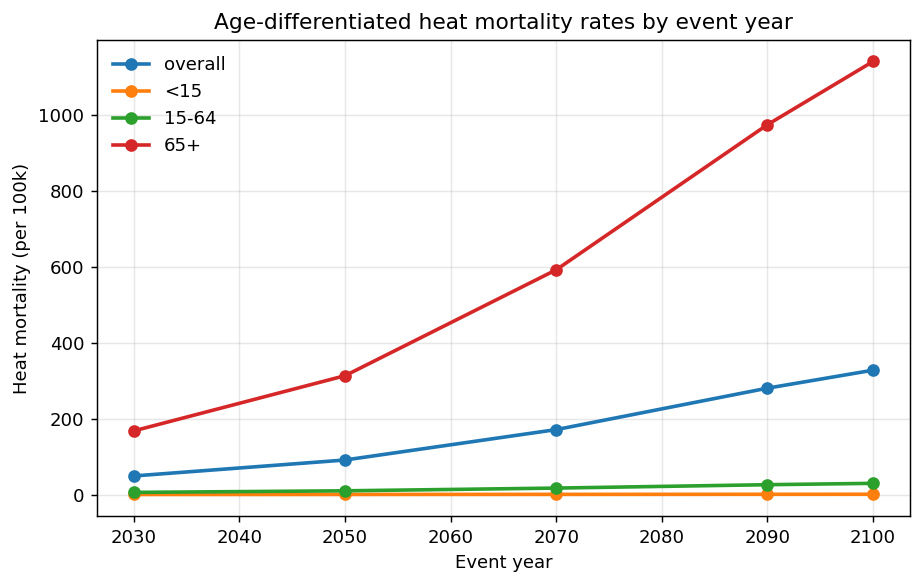

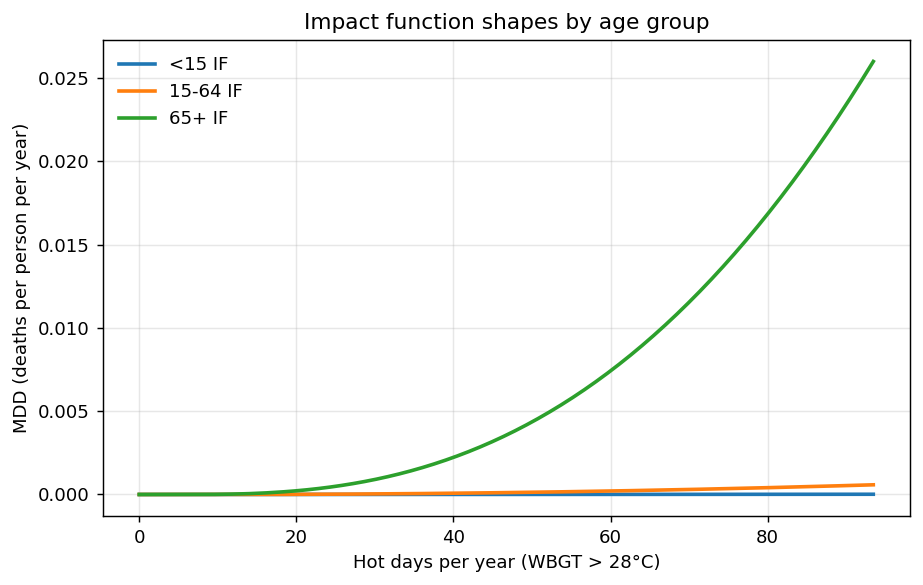

In [12]:
years_list = [int(y) for y in H.event_id.tolist()]
age_keys = ["<15", "15-64", "65+"]

df_rates = pd.DataFrame(
    {
        "overall": np.asarray(rates_all, dtype=float),
        "<15":     np.asarray(by_age["<15"]["per100k"], dtype=float),
        "15-64":   np.asarray(by_age["15-64"]["per100k"], dtype=float),
        "65+":     np.asarray(by_age["65+"]["per100k"], dtype=float),
    },
    index=years_list,
).sort_index()

# Plot 1: per-100k over events
plt.figure(figsize=(7.2, 4.6))
for col in ["overall"] + age_keys:
    plt.plot(df_rates.index.values, df_rates[col].values,
             marker="o", linewidth=2.0, label=col)
plt.xlabel("Event year")
plt.ylabel("Heat mortality (per 100k)")
plt.title("Age-differentiated heat mortality rates by event year")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

# Plot 2: IF shapes (MDD curves)
plt.figure(figsize=(7.2, 4.6))
for k in age_keys:
    f = age_ifs[k]
    plt.plot(f.intensity, f.mdd, linewidth=2.0, label=f"{k} IF")
plt.xlabel("Hot days per year (WBGT > 28°C)")
plt.ylabel("MDD (deaths per person per year)")
plt.title("Impact function shapes by age group")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

> **Impact Funtions in Climada:**
> - The first plot shows expected heat mortality per 100k people, by year/event. It rises sharply with hotter futures (2030 → 2100).
> - The elderly group (65+) dominates both in rate and in absolute number of deaths. Working-age adults (15–64) are lower, children are tiny in absolute numbers.
> - The second plot shows the impact functions (IFs). They are increasing, convex curves: more extremely hot days means sharply higher annual heat mortality per person. The elderly curve starts “hurting” after fewer extreme days and climbs faster.

In [13]:
# event "2050"
years_list = [int(y) for y in H.event_id.tolist()]
i2050 = years_list.index(2050)

base = BASELINE_PER100K  # using the WCDE baseline per 100k we defined above

shares_by_age = {
    a: (float(by_age[a]["per100k"][i2050]) / base[a]) if base[a] > 0 else np.nan
    for a in base
}

overall_baseline = sum(
    base[a] * (age_pop_local[a]/age_pop_local.sum())
    for a in base
)

overall_share = float(rates_all[i2050]) / overall_baseline

print("Heat share 2050 by age:", shares_by_age)
print("Overall baseline per 100k:", overall_baseline)
print("Overall heat share 2050:", overall_share)

for a in base:
    print(a, "deaths 2050:", float(by_age[a]["totals"][i2050]))
print("Total 2050:", float(totals_all[i2050]))

# summary table
out = []
for a in ["<15","15-64","65+"]:
    rate = float(by_age[a]["per100k"][i2050])
    tot  = float(by_age[a]["totals"][i2050])
    out.append({
        "age": a,
        "baseline_allcause_per100k": base[a],
        "heat_per100k_2050": rate,
        "heat_share": rate / base[a] if base[a] > 0 else np.nan,
        "heat_deaths_2050": tot,
    })

out.append({
    "age": "overall",
    "baseline_allcause_per100k": float(overall_baseline),
    "heat_per100k_2050": float(rates_all[i2050]),
    "heat_share": overall_share,
    "heat_deaths_2050": float(totals_all[i2050]),
})

pd.DataFrame(out)

Heat share 2050 by age: {'<15': 0.16963600893595238, '15-64': 0.14068641010957247, '65+': 0.10006017855635134}
Overall baseline per 100k: 891.6975076029137
Overall heat share 2050: 0.10205254497641104
<15 deaths 2050: 0.7999370092670396
15-64 deaths 2050: 155.76935439658553
65+ deaths 2050: 2164.281610922502
Total 2050: 2320.8509023283546


,age,baseline_allcause_per100k,heat_per100k_2050,heat_share,heat_deaths_2050
0,<15,1.700000,0.288381,0.169636,0.799937
1,15-64,70.000000,9.848049,0.140686,155.769354
2,65+,3129.000000,313.088299,0.100060,2164.281611
3,overall,891.697508,91.000000,0.102053,2320.850902


> **Interpretation:**
> - “baseline_allcause_per100k” is: if we take all deaths (not just heat), how many people per 100k die in that age group in a typical year.
> - “heat_per100k_2050” is: according to our hazard (WBGT>28°C days) and IF, how many of those deaths are caused by heat in the 2050 climate.
> - “heat_share” is the share of all deaths that we attribute to heat.
> - “heat_deaths_2050” is absolute expected heat deaths in that age group in Rome FUA-equivalent area.

In [14]:
# For the notebook 5 and after
import numpy as np, json

IF_FREEZE = {
    k: {
        "id": int(f.id),
        "name": f.name,
        "intensity": np.asarray(f.intensity, float).tolist(),
        "mdd":       np.asarray(f.mdd, float).tolist(),
    }
    for k, f in age_ifs.items()
}

with open(INT / "if_curves_frozen.json", "w") as fh:
    json.dump(IF_FREEZE, fh)
print("Wrote", INT / "if_curves_frozen.json")

Wrote /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/interim/if_curves_frozen.json
